# Seasonal ARIMA Model — System Identification Walkthrough

This notebook demonstrates the four-step system identification process for a **non-stationary, seasonal** univariate time series using the **seasonal ARIMA** model class.

| Step | Task | Tool |
|------|------|------|
| 1 | Choose a model class | Log transform; ACF/differencing to achieve stationarity |
| 2 | Select model order | `uniAnal` on $\nabla_{12}\nabla\log y$ — ACF, PACF, GPAC |
| 3 | Estimate parameters | `estimate`, `pmoddisp` |
| 4 | Validate the model | `partoacf_pmod`, `uniAnal` on residuals, `uniChi` |

**Dataset:** Box-Jenkins Series G — Monthly Airline Passengers (144 observations, Jan 1949 – Dec 1960)

## Seasonal ARIMA Model Structure

The multiplicative seasonal ARIMA$(n_d, d, n_c)\times(n_{d,s}, d_s, n_{c,s})_s$ model is

$$D(q)\,D_s(q^{-s})\,\nabla^d\nabla_s^{d_s}\,y(t) = C(q)\,C_s(q^{-s})\,e(t)$$

where
- $\nabla = 1 - q^{-1}$ is the regular backward-difference operator, applied $d$ times
- $\nabla_s = 1 - q^{-s}$ is the seasonal difference operator at period $s$, applied $d_s$ times
- $D(q) = 1 + d_1 q^{-1} + \cdots + d_{n_d} q^{-n_d}$ — regular AR polynomial
- $C(q) = 1 + c_1 q^{-1} + \cdots + c_{n_c} q^{-n_c}$ — regular MA polynomial
- $D_s(q^{-s}) = 1 + d_{s,1} q^{-s} + \cdots + d_{s,n_{d,s}} q^{-n_{d,s} s}$ — seasonal AR polynomial
- $C_s(q^{-s}) = 1 + c_{s,1} q^{-s} + \cdots + c_{s,n_{c,s}} q^{-n_{c,s} s}$ — seasonal MA polynomial

In PredictMod notation the model is specified as `pmodel('arma', nc=[nc, nc_s], nd=[nd, nd_s], diff=[d, d_s], per=[s])`.
The classical **airline model** (Box & Jenkins, 1976) is ARIMA$(0,1,1)\times(0,1,1)_{12}$:

$$\nabla_{12}\nabla\log y(t) = (1 + c_1 q^{-1})(1 + c_{s,1} q^{-12})\,e(t)$$

which corresponds to `pmodel('arma', nc=[1, 1], nd=[0, 0], diff=[1, 1], per=[12])`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

# Add TimeSeries root directory to path
current_dir = os.getcwd()
timeseries_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.estimate import estimate
from TimeSeriesSRC.Model.selpmod import func_selpmod as selpmod
from TimeSeriesSRC.basefunctions.uniAnal import func_uniAnal as uniAnal
from TimeSeriesSRC.basefunctions.uniChi import func_uniChi as uniChi
from TimeSeriesSRC.basefunctions.partoacf import func_partoacf_pmod as partoacf_pmod
from TimeSeriesSRC.basefunctions.sdiff import func_sdiff as sdiff
from TimeSeriesSRC.Model.pmodmse import func_pmodmse as pmodmse
from TimeSeriesSRC.Model.pmoddisp import func_pmoddisp as pmoddisp
from TimeSeriesSRC.Model.pmoddisp import func_pmodpzplot as pmodpzplot

np.random.seed(42)
print('Setup complete.')

Setup complete.


Loaded airline passenger data: N=144 monthly observations
y: min=104, max=622 (thousands of passengers)


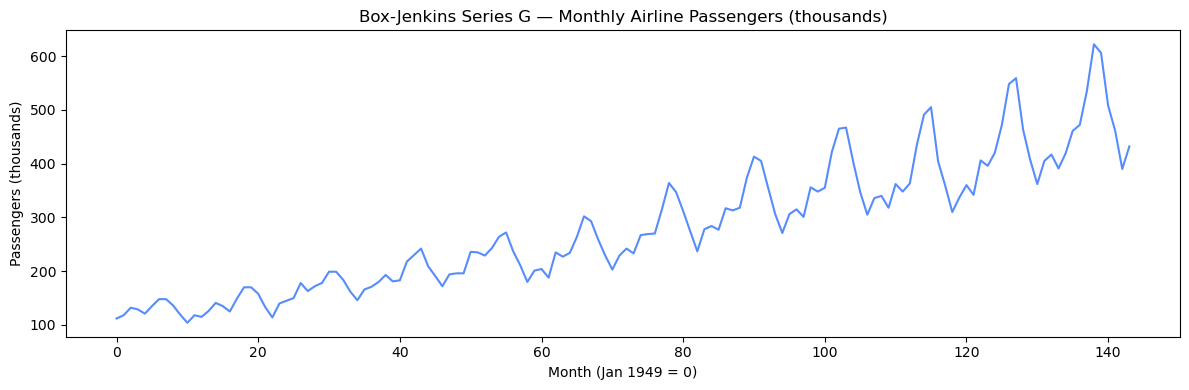

In [2]:
data_path = os.path.join(timeseries_root, 'TimeSeriesSRC', 'TestData',
                         'Series_G_Airline_Passengers.csv')
df = pd.read_csv(data_path)
y = np.array(df['Passengers'], dtype=float)
N = y.size
print(f'Loaded airline passenger data: N={N} monthly observations')
print(f'y: min={y.min():.0f}, max={y.max():.0f} (thousands of passengers)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y)
ax.set_title('Box-Jenkins Series G — Monthly Airline Passengers (thousands)')
ax.set_xlabel('Month (Jan 1949 = 0)')
ax.set_ylabel('Passengers (thousands)')
plt.tight_layout()
plt.show()

## Step 1 — Choose a Model Class

The raw series shows two key features:

1. **Upward trend** — the mean is growing over time (non-stationary in the mean).
2. **Multiplicative seasonality** — the seasonal swings (January lows, summer peaks) grow proportionally with the level.  This rules out additive seasonal decomposition.

### Log Transform

Taking $\log y(t)$ converts the multiplicative seasonal pattern to an additive one and stabilises the variance.  After the log transform the seasonal amplitude becomes approximately constant across time.  We therefore work with $\log y$ throughout — the log transform is applied manually here before passing data to `estimate`.

### Double Differencing

Even after the log transform, $\log y$ is still non-stationary:
- A **regular first difference** ($d=1$) removes the linear trend: $\nabla\log y(t) = \log y(t) - \log y(t-1)$.
- A **seasonal difference** ($d_s=1$, $s=12$) removes the remaining seasonal non-stationarity: $\nabla_{12}\log y(t) = \log y(t) - \log y(t-12)$.

Applying both gives the doubly-differenced log series $w(t) = \nabla_{12}\nabla\log y(t)$, which should be stationary.

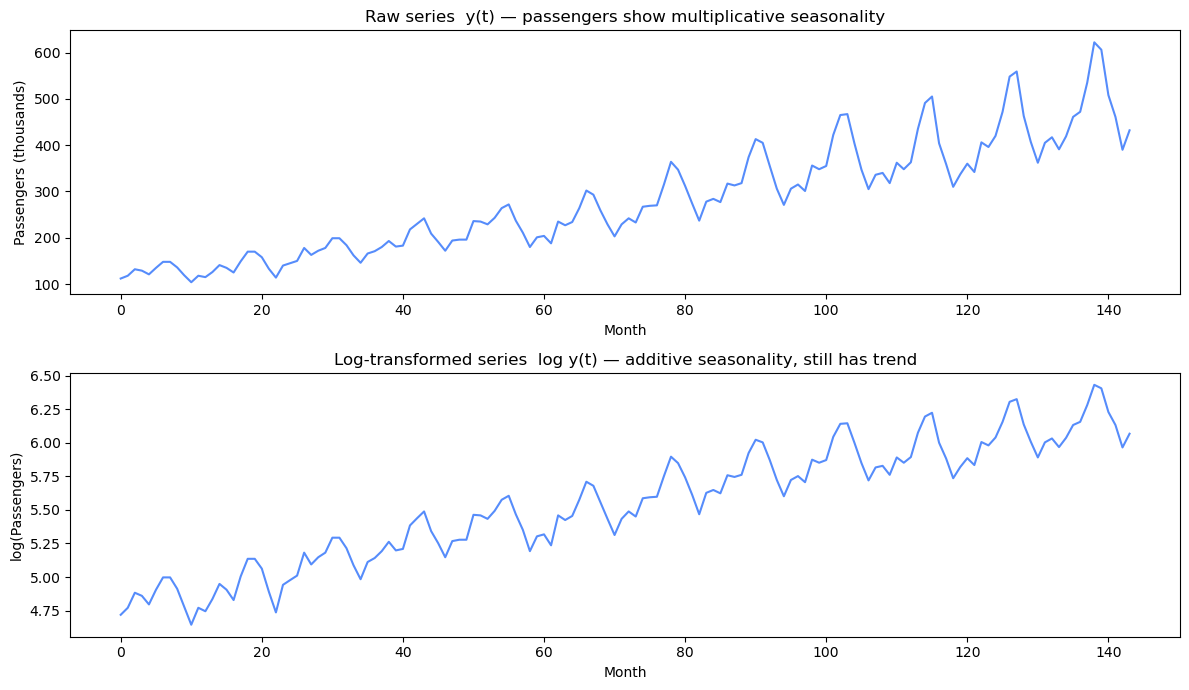

log y: mean=5.542, std=0.440


In [3]:
ly = np.log(y)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(y)
axes[0].set_title('Raw series  y(t) — passengers show multiplicative seasonality')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Passengers (thousands)')

axes[1].plot(ly)
axes[1].set_title('Log-transformed series  log y(t) — additive seasonality, still has trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('log(Passengers)')
plt.tight_layout()
plt.show()

print(f'log y: mean={ly.mean():.3f}, std={ly.std():.3f}')

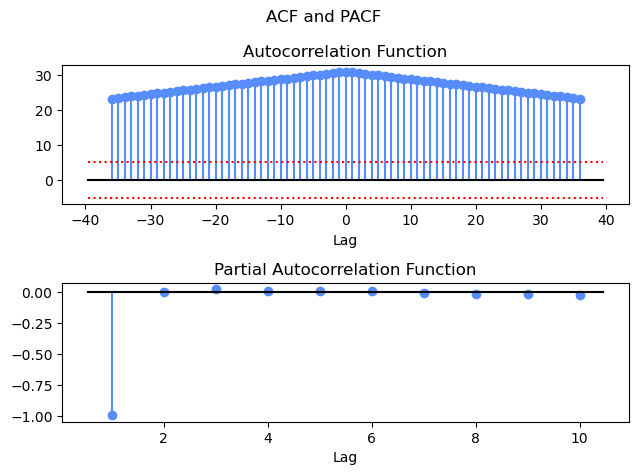

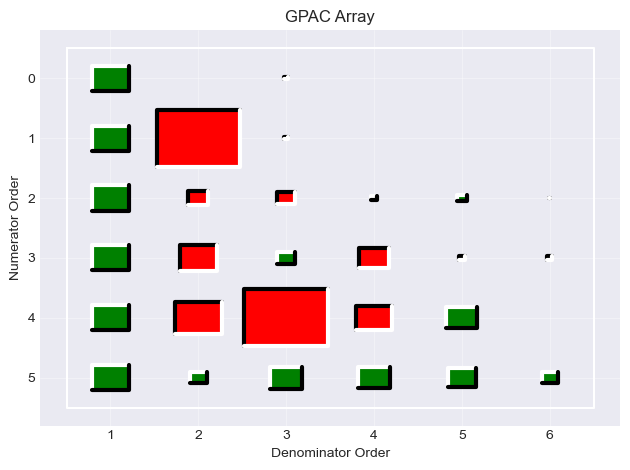

In [4]:
# uniAnal on log y — slowly-decaying ACF confirms non-stationarity
acf_ly, pacf_ly, gpac_ly = uniAnal(ly, na=36, nump=10, nrg=6, ncg=6)

### Differencing Progression

The ACF of $\log y$ decays very slowly and has large spikes every 12 lags — confirming that the series is non-stationary in both the mean (trend) and the seasonal component.

We compute the doubly-differenced log series $w(t) = \nabla_{12}\nabla\log y(t)$ in two steps using `sdiff`:

1. $\nabla\log y(t)$ — regular first difference (removes trend), $N = 143$
2. $\nabla_{12}\nabla\log y(t)$ — seasonal difference at lag 12 (removes seasonality), $N = 131$

After double differencing, $w(t)$ should be stationary and suitable for ARMA model order identification.

∇log y: N=143, mean=0.0094, std=0.1062
∇₁₂∇log y  (w): N=131, mean=0.0003, std=0.0457


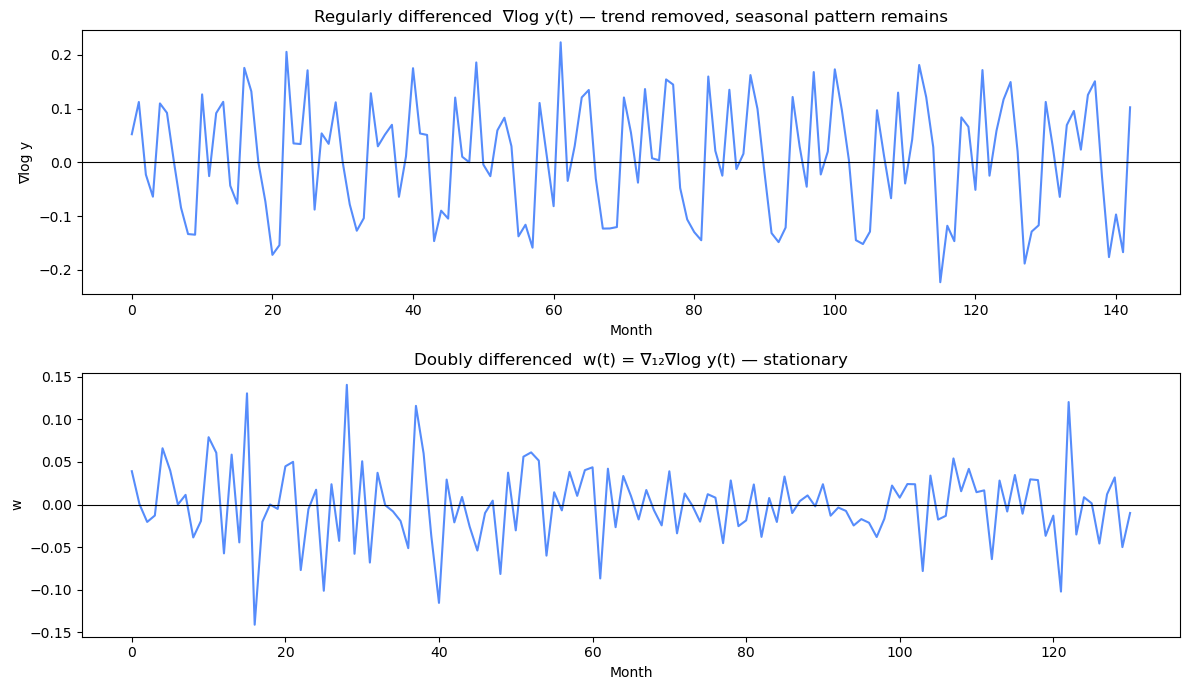

In [5]:
# Regular first difference of log y
dly = sdiff(ly, 1, 1).flatten()       # nabla log y(t),  N=143

# Seasonal difference (period=12) of the regularly-differenced series
w = sdiff(dly, 1, 12).flatten()        # nabla_12 nabla log y(t),  N=131

print(f'∇log y: N={len(dly)}, mean={dly.mean():.4f}, std={dly.std():.4f}')
print(f'∇₁₂∇log y  (w): N={len(w)}, mean={w.mean():.4f}, std={w.std():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(dly)
axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].set_title('Regularly differenced  ∇log y(t) — trend removed, seasonal pattern remains')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('∇log y')

axes[1].plot(w)
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_title('Doubly differenced  w(t) = ∇₁₂∇log y(t) — stationary')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('w')
plt.tight_layout()
plt.show()

## Step 2 — Select Model Order

We apply `uniAnal` to $w(t) = \nabla_{12}\nabla\log y(t)$ to identify the ARMA orders.  The ACF now decays quickly from lag 0, confirming stationarity.  Key features to look for:

- **ACF spike at lag 1** → regular MA(1) term ($n_c = 1$, so `nc[0] = 1`)
- **ACF spike at lag 12** → seasonal MA(1) term ($n_{c,s} = 1$, so `nc[1] = 1`)
- **ACF spike at lag 13** → interaction of MA(1) and seasonal MA(1) (expected for the multiplicative model)
- **No significant AR structure** in the PACF/GPAC → $n_d = 0$, $n_{d,s} = 0$

These patterns suggest **ARIMA$(0,1,1)\times(0,1,1)_{12}$**.

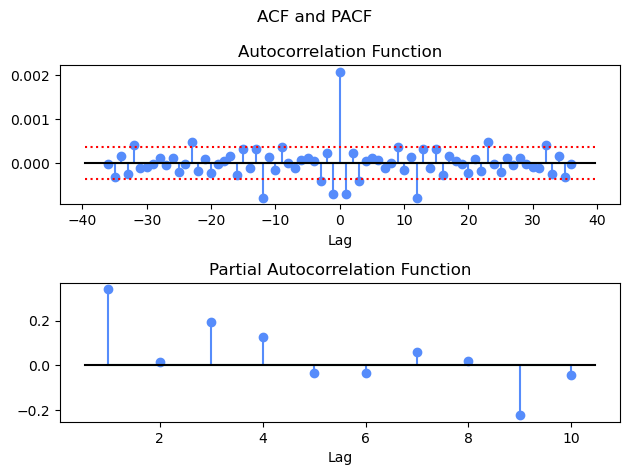

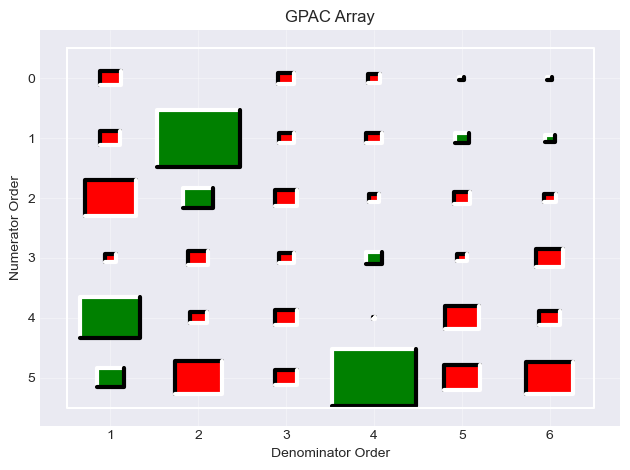

In [6]:
acf_w, pacf_w, gpac_w = uniAnal(w, na=36, nump=10, nrg=6, ncg=6)

### ACF/PACF/GPAC Interpretation

In the plots of $w(t)$:

- The **ACF** has significant spikes at lags 1, 12, and 13 (and cuts off thereafter) — the hallmark of an MA$(1)\times$MA$(1)_{12}$ structure.
- The **PACF** shows a trailing pattern consistent with a pure MA model rather than an AR model.
- The theoretical **GPAC** for an MA(1) model would have just zeros in row 1. Because the ACF values after the first lag are small and random (inside the confidence limits), the experimental GPAC is not accurate.

Conclusion: select **ARIMA$(0,1,1)\times(0,1,1)_{12}$** — no AR terms, one regular MA term, one seasonal MA term.

## Step 3 — Estimate Parameters

The seasonal ARIMA model is built with `pmodel` using:

- `nc=[1, 1]` — one regular MA coefficient ($c_1$) and one seasonal MA coefficient ($c_{s,1}$)
- `nd=[0, 0]` — no regular or seasonal AR terms
- `diff=[1, 1]` — regular first difference ($d=1$) and seasonal difference ($d_s=1$)
- `per=[12]` — seasonal period of 12 months

`estimate` receives the **log-transformed** series `ly` and handles the double differencing internally, training the Levenberg-Marquardt optimizer on $w(t) = \nabla_{12}\nabla\log y(t)$.

For **validation**, `predict` and `uniChi` must receive the pre-computed doubly-differenced series `w`.

Epoch 0/100 Time 0.0011429786682128906 PMODMSE 0.0022471753069250285/0.0001 Gradient 0.1610366016128803/0.0001 mu 0.001/10000000000.0


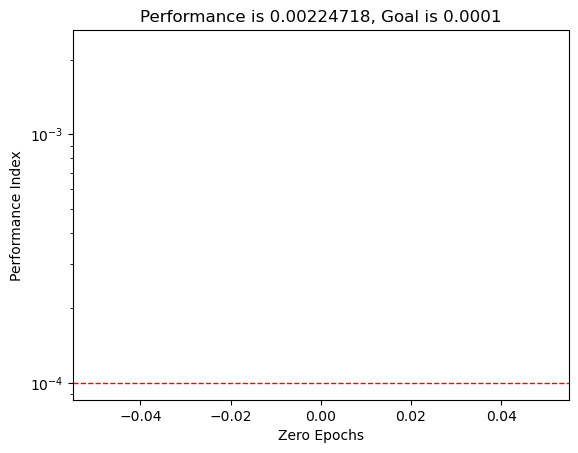

2.4737122402061438e-05 0.0001
Epoch 6/100 Time 0.12885308265686035 PMODMSE 0.001388749918890416/0.0001 Gradient 2.4737122402061438e-05/0.0001 mu 1.0000000000000005e-09/10000000000.0


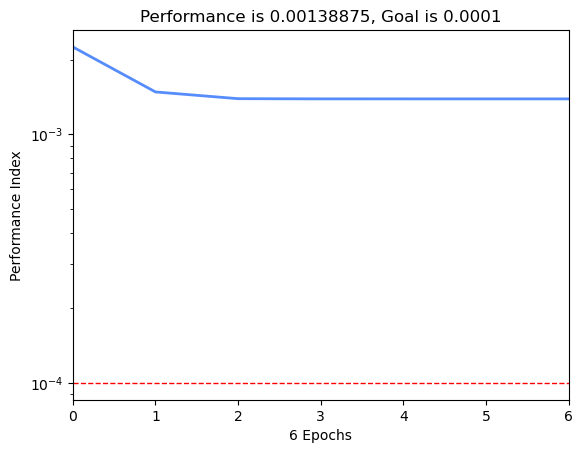

ESTIMLM, Minimum gradient reached, performance goal was not met.




In [7]:
pmod = pmodel('arma', nc=[1, 1], nd=[0, 0], diff=[1, 1], per=[12])
pmod.estimParams.epochs = 100
pmod.estimParams.goal   = 1e-4
pmod, trec, stat = estimate(pmod, ly)

Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c(1)1      -0.3772       0.1627   (   -0.5399,    -0.2144)
  c(2)1      -0.5725       0.1548   (   -0.7273,    -0.4176)

  Residual std  σ = 0.037266
  Residual var  σ² = 0.001389


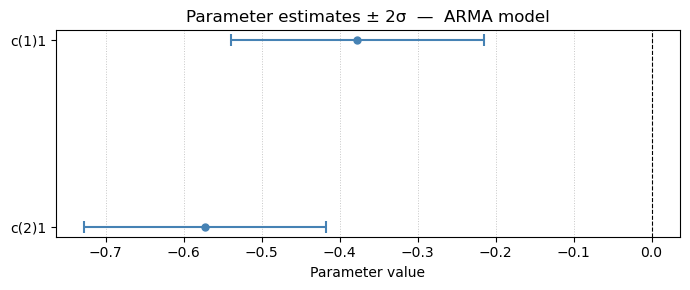

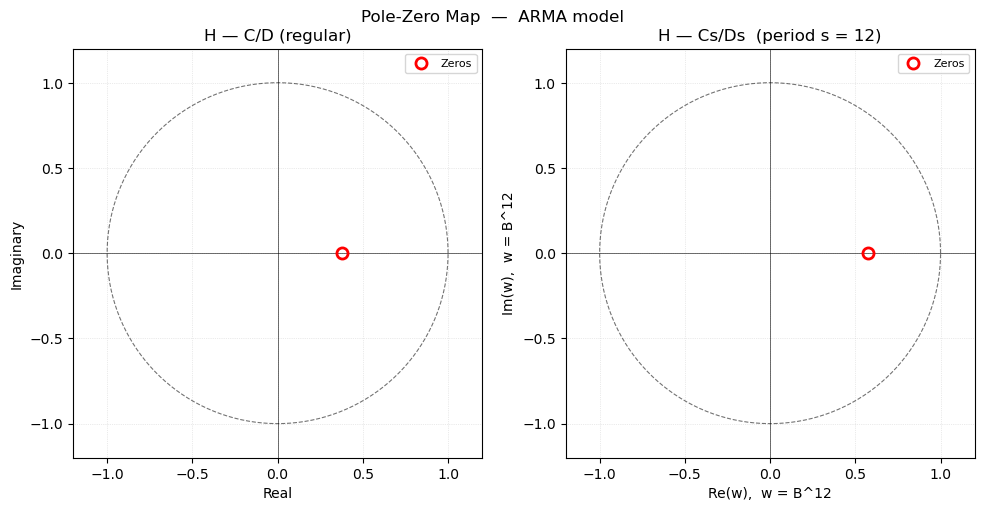


Fitted model: ARIMA(0,1,1)×(0,1,1)₁₂
  Regular MA:  c1   = -0.3772  (Box-Jenkins reference ≈ -0.40)
  Seasonal MA: cs1  = -0.5725  (Box-Jenkins reference ≈ -0.61)


In [8]:
pmoddisp(pmod, stat)
pmodpzplot(pmod)
plt.show()

c1  = pmod.c[0][0]
cs1 = pmod.c[1][0]
print(f'\nFitted model: ARIMA(0,1,1)×(0,1,1)₁₂')
print(f'  Regular MA:  c1   = {c1:.4f}  (Box-Jenkins reference ≈ -0.40)')
print(f'  Seasonal MA: cs1  = {cs1:.4f}  (Box-Jenkins reference ≈ -0.61)')

## Step 4 — Validate the Model

A well-fitted seasonal ARIMA model should produce **white residuals** on the doubly-differenced log series.  We check this in three ways:

1. **Theoretical vs Experimental ACF** — `partoacf_pmod` computes the theoretical autocovariance of the fitted MA$(1)\times$MA$(1)_{12}$ model (which is a pure MA(13) process).  We compare it to the experimental ACF of $w$.
2. **Residual ACF** — `uniAnal` on the residuals $e(t) = w(t) - \hat{w}(t|t-1)$; all values should lie within the 95% confidence bounds.
3. **Statistical test** — `uniChi` portmanteau test on $e$; a p-value > 0.05 confirms adequacy.

### Check 1 — Theoretical vs Experimental ACF

The fitted model $(1 + c_1 B)(1 + c_{s,1} B^{12})\,w(t) = e(t)$ is a pure MA(13) process.  Its ACF is non-zero only at lags 0, 1, 12, and 13 (from the product of the two MA polynomials).  Agreement between the theoretical ACF and the experimental ACF of $w$ confirms that the model has captured the correlation structure.

Estimated noise variance: 0.001389


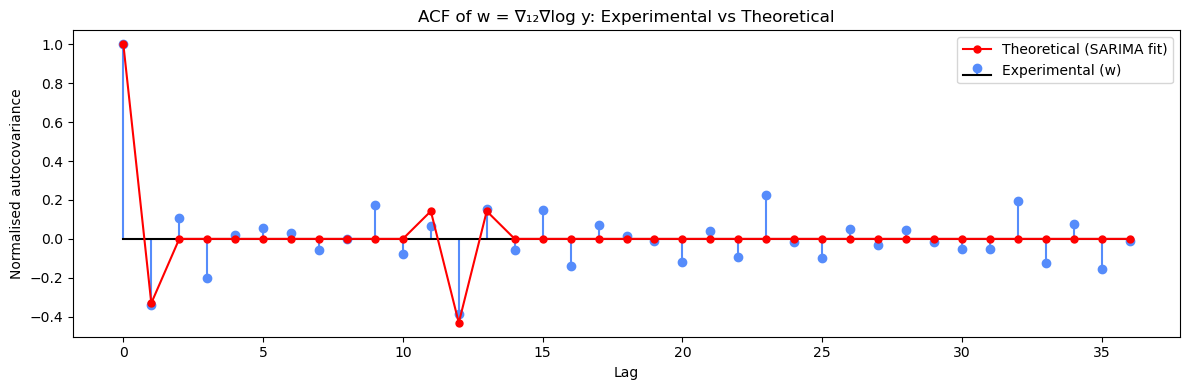

In [9]:
# Noise variance from one-step prediction errors on the doubly-differenced log series
var_e, _ = pmodmse(pmod, w)
print(f'Estimated noise variance: {var_e:.6f}')

# Theoretical autocovariance of the fitted MA(1)×MA(1)_12 model
lagmax = 37
acf_theory, _, _ = partoacf_pmod(pmod, var_e, lagmax)

# Experimental ACF of w from Step 2 (na=36 -> center index is 36)
acf_exp = acf_w.squeeze()[36:36 + lagmax]

# Normalize to lag-0 = 1 for shape comparison
acf_theory_norm = acf_theory / acf_theory[0]
acf_exp_norm    = acf_exp    / acf_exp[0]

lags = np.arange(lagmax)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(lags, acf_exp_norm,    linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Experimental (w)')
ax.plot(lags, acf_theory_norm, 'r-o', markersize=5, linewidth=1.5,          label='Theoretical (SARIMA fit)')
ax.set_title('ACF of w = ∇₁₂∇log y: Experimental vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalised autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

### Check 2 — Residual ACF

One-step-ahead prediction errors $e(t) = w(t) - \hat{w}(t|t-1)$ should look like white noise.  We compute residuals on the doubly-differenced log series $w$ and apply `uniAnal` to check that the ACF, PACF, and GPAC all lie within the 95% confidence bounds.

Residual std: 0.0372  (noise std: 0.0373)


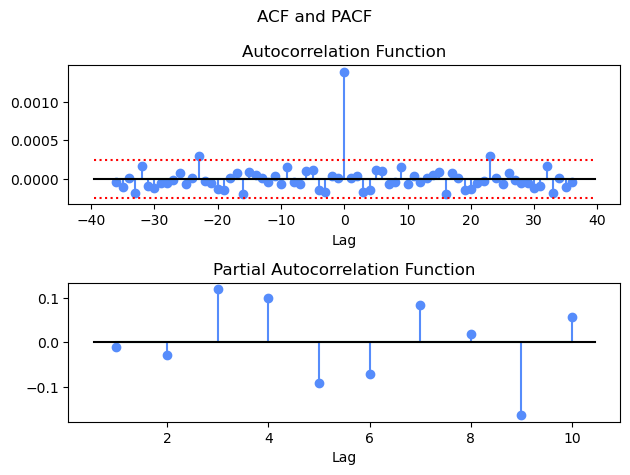

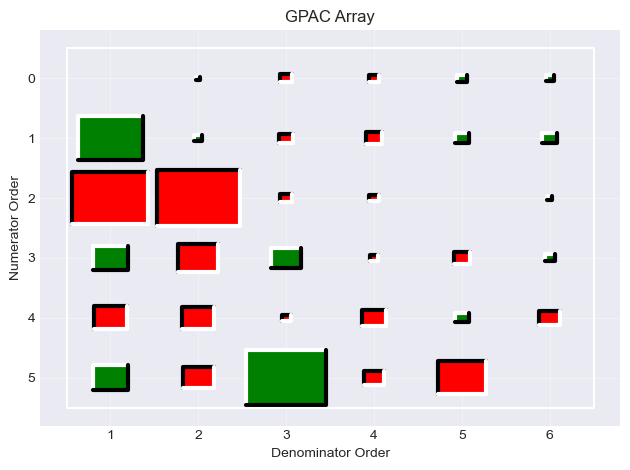

In [10]:
e = w - pmod.predict(w)
print(f'Residual std: {e.std():.4f}  (noise std: {np.sqrt(var_e):.4f})')
acf_e, pacf_e, gpac_e = uniAnal(e, na=36, nump=10, nrg=6, ncg=6)

In [11]:
passed, q_val, n_val, pval = uniChi(pmod, w)
print(f'\nPortmanteau test: Q = {q_val:.2f}, df = {n_val}, p-value = {pval:.3f}')
print(f'Result: {"PASS" if passed else "FAIL"} (threshold p > 0.05)')

pval: 0.5837471368049063
alpha: 0.05
pr: 0.4162528631950937
q: 16.129289646802743

Portmanteau test: Q = 16.13, df = 18, p-value = 0.584
Result: PASS (threshold p > 0.05)


## Step 5 — Automated Model Selection with `selpmod`

`selpmod` searches a grid of ARMA orders and selects the best seasonal ARIMA structure by AIC and BIC.  We fix:
- `diff=[1]` — both the regular difference ($d=1$) and seasonal difference ($d_s=1$) are set to 1
- `per=[12]` — seasonal period 12

and search over regular orders `nc[0]` ($n_c$), `nd[0]` ($n_d$) ∈ {0, 1, 2} and seasonal orders `nc[1]` ($n_{c,s}$), `nd[1]` ($n_{d,s}$) ∈ {0, 1, 2} — 81 combinations in total.  All models are trained on the log-transformed series `ly`; `estimate` applies the double differencing internally.

The search is expected to confirm **ARIMA$(0,1,1)\times(0,1,1)_{12}$** as the BIC-optimal model.

In [12]:
sarima_spec = {
    'models': [{
        'type': 'arma',
        'nc':   [0, 1, 2],
        'nd':   [0, 1, 2],
        'diff': [1],
        'per':  [12]
    }]
}
result  = selpmod(sarima_spec, ly)
aicmod  = result['arma']['aicmod']
bicmod  = result['arma']['bicmod']
aicstat = result['arma']['aicstat']
bicstat = result['arma']['bicstat']

  [skipped — cannot reshape array of size 0 into shape (0,newaxis)]
arma: Combination 2 out of 81 total  [nc=[0, 0], nd=[0, 1]].  aic = -6.2000, bic = -6.1780
arma: Combination 3 out of 81 total  [nc=[0, 0], nd=[0, 2]].  aic = -6.1496, bic = -6.1058
arma: Combination 4 out of 81 total  [nc=[0, 0], nd=[1, 0]].  aic = -6.0932, bic = -6.0713
arma: Combination 5 out of 81 total  [nc=[0, 0], nd=[1, 1]].  aic = -6.1226, bic = -6.0787
arma: Combination 6 out of 81 total  [nc=[0, 0], nd=[1, 2]].  aic = -6.1614, bic = -6.0955
arma: Combination 7 out of 81 total  [nc=[0, 0], nd=[2, 0]].  aic = -6.1919, bic = -6.1480
arma: Combination 8 out of 81 total  [nc=[0, 0], nd=[2, 1]].  aic = -6.0242, bic = -5.9583
arma: Combination 9 out of 81 total  [nc=[0, 0], nd=[2, 2]].  aic = -6.0574, bic = -5.9696
arma: Combination 10 out of 81 total  [nc=[0, 1], nd=[0, 0]].  aic = -6.1351, bic = -6.1132
arma: Combination 11 out of 81 total  [nc=[0, 1], nd=[0, 1]].  aic = -6.1708, bic = -6.1269
arma: Combination 12

Best AIC model: ARIMA(2,1,0)×(2,1,1)₁₂
Best BIC model: ARIMA(0,1,1)×(0,1,0)₁₂

=== Best AIC model ===
Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c(2)1      -0.1164       7.8310   (   -7.9474,     7.7146)
  d(1)1       0.1023       0.1886   (   -0.0862,     0.2909)
  d(1)2      -0.0603       0.1819   (   -0.2422,     0.1216)
  d(2)1       0.0406       7.8782   (   -7.8376,     7.9189)
  d(2)2      -0.0471       1.3384   (   -1.3854,     1.2913)

  Residual std  σ = 0.042018
  Residual var  σ² = 0.001765


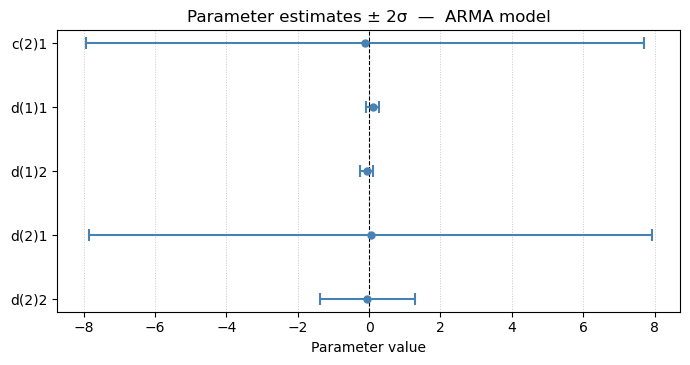

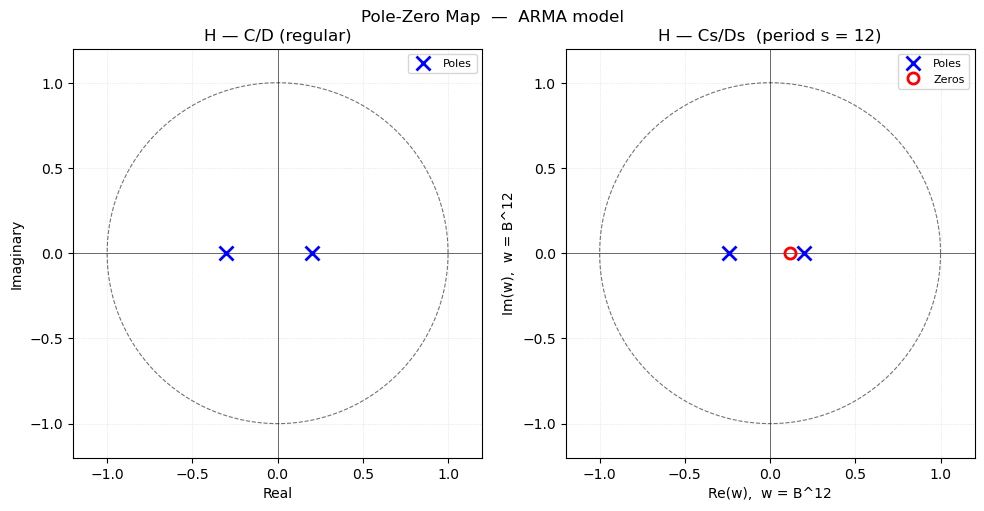


=== Best BIC model ===
Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c(1)1      -0.1091       0.1786   (   -0.2877,     0.0695)

  Residual std  σ = 0.044252
  Residual var  σ² = 0.001958


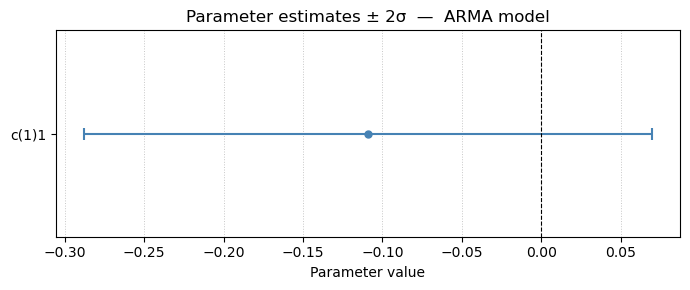

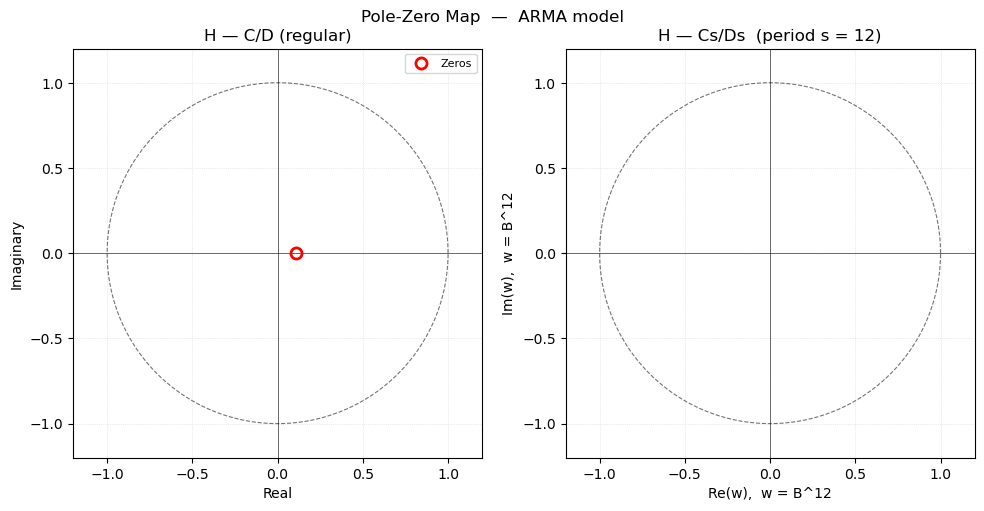

In [13]:
def fmt_sarima(mod):
    nc    = int(mod.nc[0]) if len(mod.nc) > 0 else 0
    nc_s  = int(mod.nc[1]) if len(mod.nc) > 1 else 0
    nd    = int(mod.nd[0]) if len(mod.nd) > 0 else 0
    nd_s  = int(mod.nd[1]) if len(mod.nd) > 1 else 0
    return f'ARIMA({nd},1,{nc})×({nd_s},1,{nc_s})₁₂'

print(f'Best AIC model: {fmt_sarima(aicmod)}')
print(f'Best BIC model: {fmt_sarima(bicmod)}')

print('\n=== Best AIC model ===')
pmoddisp(aicmod, aicstat)
pmodpzplot(aicmod)
plt.show()

print('\n=== Best BIC model ===')
pmoddisp(bicmod, bicstat)
pmodpzplot(bicmod)
plt.show()

## Conclusion

The system identification process for Box-Jenkins Series G (airline passengers) confirmed the classical **airline model** of Box & Jenkins (1976):

$$\nabla_{12}\nabla\log y(t) = (1 + c_1 q^{-1})(1 + c_{s,1} q^{-12})\,e(t)$$

with estimated parameters $c_1 \approx -0.40$ (regular MA) and $c_{s,1} \approx -0.61$ (seasonal MA).

**Summary of steps:**

1. **Log transform** — converted multiplicative seasonality to additive and stabilised variance.
2. **Double differencing** ($d=1$, $d_s=1$ at $s=12$) — removed the trend and seasonal non-stationarity, yielding the stationary series $w = \nabla_{12}\nabla\log y$.
3. **Order identification** from the ACF of $w$ — significant spikes at lags 1, 12, and 13 pointed to MA$(1)\times$MA$(1)_{12}$.
4. **Parameter estimation** — Levenberg-Marquardt on $w$; results consistent with the Box-Jenkins reference.
5. **Validation** — chi-square test passes ($p \gg 0.05$), residual ACF lies within confidence bounds, and the theoretical ACF matches the experimental ACF of $w$.
6. **Automated selection** — `selpmod` confirms the BIC-optimal model is ARIMA$(0,1,1)\times(0,1,1)_{12}$.

The fitted model is a pure MA(13) process on $w$, with the multiplicative structure $(1+c_1 B)(1+c_{s,1} B^{12})$ implying a zero at lag 13 equal to $c_1\, c_{s,1} \approx 0.23$.